# **--- GETAROUND PROJECT (delay analysis)---** #

## **1. Libraries import** ##

In [ ]:
import pandas as pd
import numpy as np
import os
import json


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

## **2. Data import and first observations** ##

In [191]:
# Dataset import
raw_df=pd.read_excel("../DATA/raw_data/get_around_delay_analysis.xlsx")
raw_df.head()

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [192]:
# Size of the dataset
raw_df.shape

(21310, 7)

In [ ]:
# Statistical information
raw_df.describe(include="all")

In [ ]:
# Check for duplicates
raw_df.duplicated().any() 

In [193]:
# Main information on the dataset
raw_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


We can observe the presence of missing values for 3 variables : 
- `delay_at_checkout_in_minutes`,
- `previous_ended_rental_id`,
- `time_delta_with_previous_rental_in_minutes`


In [231]:
# Check for the pourcentage of missing values per column (in %)
total_nb_rentals=raw_df.shape[0]
round(100*raw_df.isna().sum()/total_nb_rentals,2)

rental_id                                      0.00
car_id                                         0.00
checkin_type                                   0.00
state                                          0.00
delay_at_checkout_in_minutes                  23.29
previous_ended_rental_id                      91.36
time_delta_with_previous_rental_in_minutes    91.36
dtype: float64

We can observe that the proportion of missing values for the variables `previous_ended_rental_id` and `time_delta_with_previous_rental_in_minutes` is very high (91.36%) and identical. This suggests that the missingness may be related either to a lack of available data or to cases where the rental corresponds to the first usage of the car.

Note: We do not have any temporal context here (for example, whether the rentals are recorded per day or over a specific time period), which limits further interpretation. 

## **3. Missing data analysis (`previous_ended_rental_id` and `time_delta`)** ##

Let's first study the missing values for the variables `previous_ended_rental_id` and `time_delta_with_previous_rental_in_minutes`. Here is our hypothesis :  
**Missing data for these variable is related to a first rental of a given car.**

### **3.1. Consistency of missing data** ###

To verify this hypothesis, we are going to check the following consistency rules:

- No previous rental: both variables should be missing simultaneously.
- Previous rental exists: both variables should be populated.

In other words, missingness should be consistent across the two columns.

In [195]:
# Conditions
both_null = raw_df['previous_ended_rental_id'].isnull() & raw_df['time_delta_with_previous_rental_in_minutes'].isnull()
both_filled = raw_df['previous_ended_rental_id'].notnull() & raw_df['time_delta_with_previous_rental_in_minutes'].notnull()
only_prev_null = raw_df['previous_ended_rental_id'].isnull() & raw_df['time_delta_with_previous_rental_in_minutes'].notnull()
only_delta_null = raw_df['previous_ended_rental_id'].notnull() & raw_df['time_delta_with_previous_rental_in_minutes'].isnull()

# Summary table
coherence_check = pd.DataFrame({
    'Scenario': [
        'Both NULL (consistent)',
        'Both FILLED (consistent)', 
        'Only previous_rental NULL (inconsistent)',
        'Only time_delta NULL (inconsistent)'
    ],
    'Count': [
        both_null.sum(),
        both_filled.sum(),
        only_prev_null.sum(),
        only_delta_null.sum()
    ],
    'Percentage': [
        (both_null.sum() / len(raw_df) * 100).round(2),
        (both_filled.sum() / len(raw_df) * 100).round(2),
        (only_prev_null.sum() / len(raw_df) * 100).round(2),
        (only_delta_null.sum() / len(raw_df) * 100).round(2)
    ]
})

coherence_check


,Scenario,Count,Percentage
0,Both NULL (consistent),19469,91.36
1,Both FILLED (consistent),1841,8.64
2,Only previous_rental NULL (inconsistent),0,0.00
3,Only time_delta NULL (inconsistent),0,0.00


Missing values are consistent across both columns, which indicates that they are associated with the absence of a previous rental during the observed period rather than with data quality issues. As a result, the analysis should focus on cases where a car has multiple consecutive rentals, as these are the situations in which delays can propagate and have an impact.

### **3.2. Number of missing data according to the number of rentals** ###

**_3.2.1. Separating cars according to their number of rentals_**

Let's now create 2 groups to devide the cars according to the number of rentals over the period: 
- first group: Cars with one rental only,
- second group: Cars with more than one rental.

In [214]:
# Numbers of cars in the dataset
total_nb_car=raw_df['car_id'].nunique()
print(f"There is a total of {total_nb_car} cars in the dataset.")

There is a total of 8143 cars in the dataset.


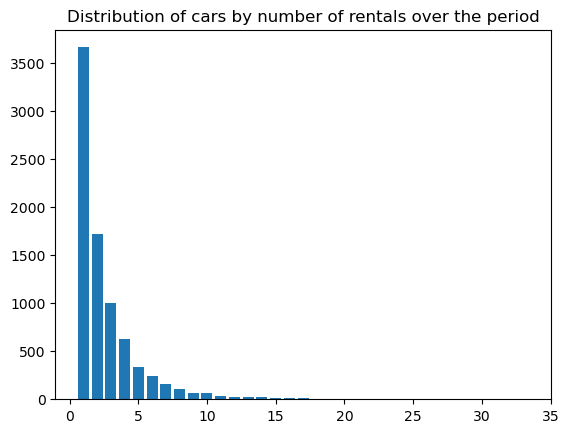

In [205]:
# Count rentals per car
nb_rentals_per_car = raw_df.groupby('car_id').size()
count_per_nb_rental = nb_rentals_per_car.value_counts()

plt.figure()
plt.bar(count_per_nb_rental.index,count_per_nb_rental.values)
plt.title("Distribution of cars by number of rentals over the period")
plt.show()

In [216]:
# Create first group (cars rented once only) :
cars_one_rental_ids = nb_rentals_per_car[nb_rentals_per_car == 1].index
nb_cars_one_rental=cars_one_rental_ids.nunique()
cars_one_rental_df=raw_df[raw_df["car_id"].isin(cars_one_rental_ids)]

print(f"Number of cars with only one rental : {nb_cars_one_rental}.\nThis represents {round((100*cars_one_rental_ids.nunique()/total_nb_car),2)}% of all cars.")

Number of cars with only one rental : 3659.
This represents 44.93% of all cars.


In [219]:
# Create second group (cars rented more than once) :
cars_several_rentals_ids = nb_rentals_per_car[nb_rentals_per_car > 1].index
nb_cars_several_rentals=cars_several_rentals_ids.nunique()
cars_several_rentals_df=raw_df[raw_df["car_id"].isin(cars_several_rentals_ids)]

print(f"Number of cars with several rentals : {nb_cars_several_rentals}.\nThis represents {round((100*cars_several_rentals_ids.nunique()/total_nb_car),2)}% of all cars.")

Number of cars with several rentals : 4484.
This represents 55.07% of all cars.


**Out of all cars in the dataset:** 

**- 44,93% have been rented only once over the period of time covered by the dataset,**

**- 55,07% have been rented more than once.**

**_3.2.2. Number of missing values in `previous_ended_rental_id` column according to how many times the car has been rented_**

In [225]:
# Cars with only one rental: all the "previous_ended_rental_id" should be NaN
nb_nan_one_rental=cars_one_rental_df['previous_ended_rental_id'].isna().count()
nb_nan_one_rental==nb_cars_one_rental

True

All cars that have been rented only once have 'NaN' values for the `previous_ended_rental_id` variable. Now let's check if cars with more than one rental, have exactly one 'NaN' for that variable. Despite the fact that we do not have chronological information, we can suppose that it would correspond to the first rental of the car.

In [232]:
# Cars with more than one rental: they should have exactly one NaN value for the "previous_ended_rental_id" variable corresponding to the first rental of consecutive rentals.
nb_nan_several_rentals=cars_several_rentals_df['previous_ended_rental_id'].isna().count()
nb_nan_several_rentals==total_nb_rentals-nb_nan_one_rental

True

Cars that have been rented more than once have exactly one NaN values in the `previous_ended_rental_id` column. We can thus vaidate our hypothesis: missing data for the variable `prevous_ended_rental_id` correspond to first rentals of: 
- cars with only one rental in total,
- cars with more than one rental (first rental of a chain of rentals).

To assess the impact of delays on cancellations, we focus on the 55.07% of cars that are involved in multiple successive rentals.
For these vehicles, we exclude the first rental in each sequence, as it cannot be affected by a prior delay.

The remaining rentals—those exposed to a potential knock-on effect from previous delays—represent 8.64% of all rentals. These rentals are therefore considered “at risk.”

In [240]:
# Select and save all rows with an "at risk" rental_id: 
risky_rentals_df=raw_df[both_filled] # we select rows with non NaN values for the previous_ended_rental_id
risky_rentals_df.to_excel("../DATA/processed_data/risky_rentals.xlsx")